# Load the dataset and plots for visualization

In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path("~/github/UPenn_Py/piml_dt_cardiac").expanduser()
sys.path.insert(0, str(base_dir))

from utils import system_dynamics
from utils_fire import get_config

config = get_config(base_dir / "config_ms.yaml")
data = config["data"]

# Convert config-relative paths to absolute paths
v_file = str(base_dir / data["v_file_name"])
w_file = str(base_dir / data["w_file_name"])
pt_file = str(base_dir / data["pt_file_name"])

print(v_file)
print(w_file)
print(pt_file + ".pts")

dyn = system_dynamics(**config)

out = dyn.generate_data(
    v_file,
    w_file,
    pt_file,
    data["scenario_name"],
    data["ionic_model_name"],
)

observe_train, observe_test, v_train, v_test, w_train, w_test, Vsav, V, len_t, idx_data_larger, Wsav, W = out

print("Vsav shape:", Vsav.shape)
print("V range:", np.nanmin(Vsav), np.nanmax(Vsav))
print("domain:")
print("x:", dyn.min_x, dyn.max_x)
print("y:", dyn.min_y, dyn.max_y)
print("t:", dyn.min_t, dyn.max_t)


ModuleNotFoundError: No module named 'utils'

### Voltage Snapshots

In [3]:
frame_ids = [0, 5, 10, 20, 40, 80, 100]
frame_ids = [i for i in frame_ids if i < Vsav.shape[2]]

ncols = 4
nrows = int(np.ceil(len(frame_ids) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 3 * nrows),
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

fig.suptitle("openCARP Mitchell-Schaeffer Voltage Snapshots", fontsize=16)

for ax, tidx in zip(axes, frame_ids):
    im = ax.imshow(
        Vsav[:, :, tidx].T,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=[dyn.min_x, dyn.max_x, dyn.min_y, dyn.max_y],
    )
    ax.set_title(f"t = {tidx} ms")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")

for ax in axes[len(frame_ids):]:
    ax.axis("off")

fig.colorbar(im, ax=axes[:len(frame_ids)], shrink=0.8, label="vm")
plt.show()


NameError: name 'Vsav' is not defined

### Voltage over time at a few fixed tissue locations

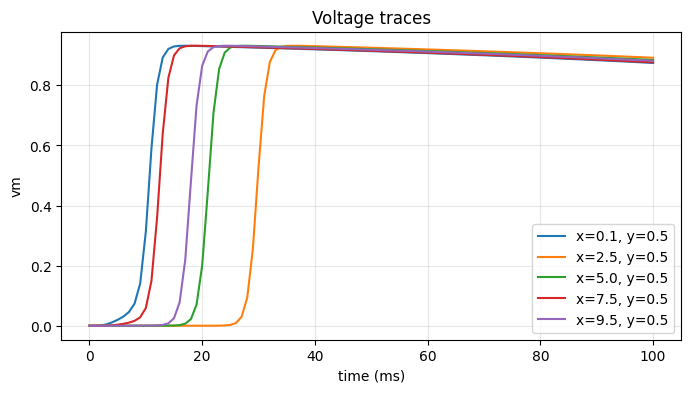

In [18]:
points = [
    (0.1, 0.5),
    (2.5, 0.5),
    (5.0, 0.5),
    (7.5, 0.5),
    (9.5, 0.5),
]

nx, ny, nt = Vsav.shape
x_vals = np.linspace(dyn.min_x, dyn.max_x, nx)
y_vals = np.linspace(dyn.min_y, dyn.max_y, ny)
t_vals = np.linspace(dyn.min_t, dyn.max_t, nt)

plt.figure(figsize=(8, 4))

for x0, y0 in points:
    ix = np.argmin(np.abs(x_vals - x0))
    iy = np.argmin(np.abs(y_vals - y0))
    plt.plot(t_vals, Vsav[ix, iy, :], label=f"x={x_vals[ix]:.1f}, y={y_vals[iy]:.1f}")

plt.xlabel("time (ms)")
plt.ylabel("vm")
plt.title("Voltage traces")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### x-time map of voltage along the tissue centerline

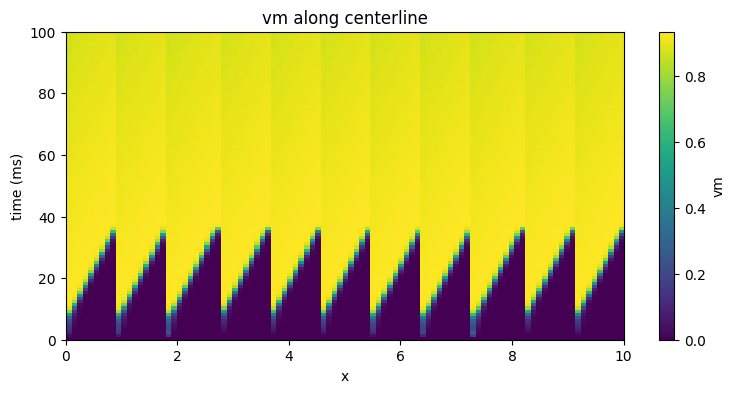

In [19]:
iy = ny // 2

plt.figure(figsize=(9, 4))
plt.imshow(
    Vsav[:, iy, :].T,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    extent=[dyn.min_x, dyn.max_x, dyn.min_t, dyn.max_t],
)
plt.xlabel("x")
plt.ylabel("time (ms)")
plt.title("vm along centerline")
plt.colorbar(label="vm")
plt.show()




### Visualize local activation times

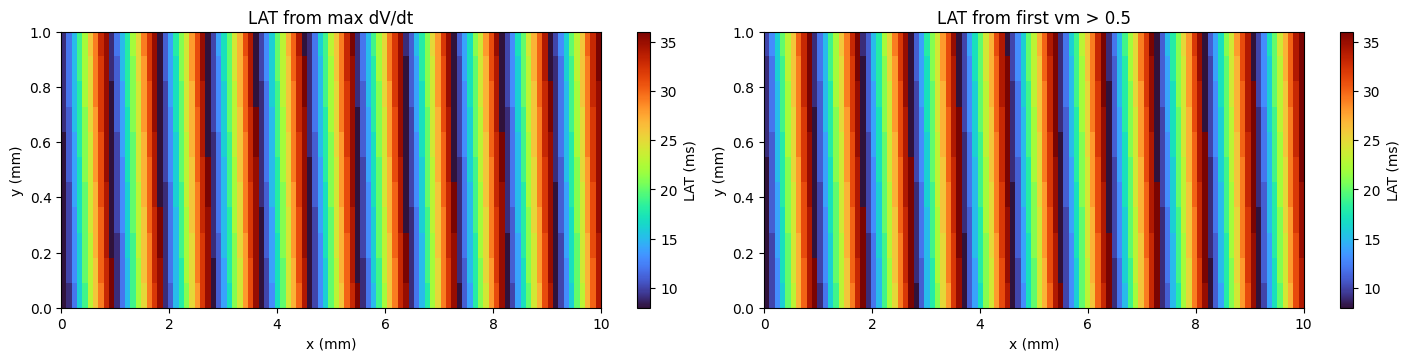

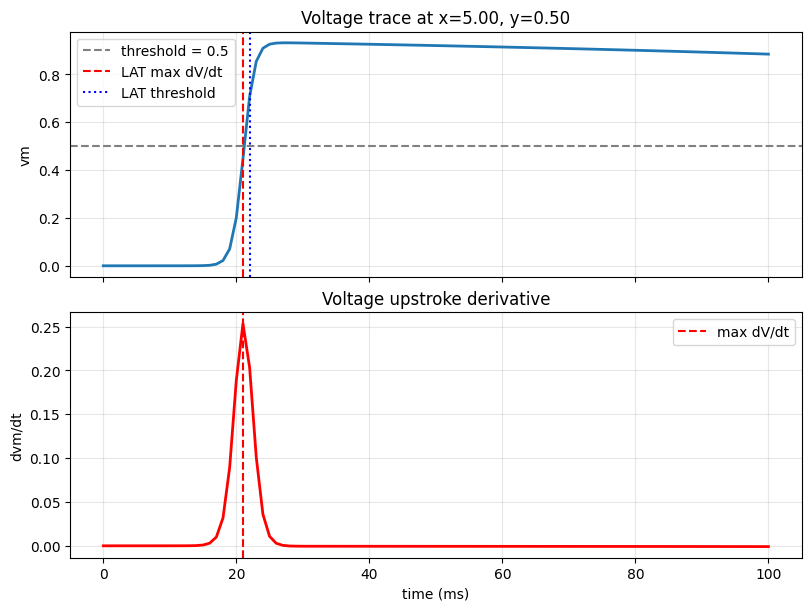

LAT dV/dt range:
min: 8.0 ms
max: 36.0 ms

LAT threshold range:
min: 8.0 ms
max: 36.0 ms


In [20]:
nx, ny, nt = Vsav.shape

x_vals = np.linspace(dyn.min_x, dyn.max_x, nx)
y_vals = np.linspace(dyn.min_y, dyn.max_y, ny)
t_vals = np.linspace(dyn.min_t, dyn.max_t, nt)

# --------------------------------------------------
# Method 1: LAT from maximum dV/dt
# --------------------------------------------------

dt = t_vals[1] - t_vals[0]

dvm_dt = np.gradient(Vsav, dt, axis=2)

lat_idx = np.argmax(dvm_dt, axis=2)
LAT_dvdt = t_vals[lat_idx]

# Mask points that never activated
activation_threshold = 0.5
activated = np.max(Vsav, axis=2) > activation_threshold

LAT_dvdt_masked = LAT_dvdt.copy()
LAT_dvdt_masked[~activated] = np.nan

# --------------------------------------------------
# Method 2: LAT from first threshold crossing
# --------------------------------------------------

crossed = Vsav > activation_threshold
first_cross_idx = np.argmax(crossed, axis=2)

LAT_crossing = t_vals[first_cross_idx]
LAT_crossing[~np.any(crossed, axis=2)] = np.nan

# --------------------------------------------------
# Plot LAT maps
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), constrained_layout=True)

im0 = axes[0].imshow(
    LAT_dvdt_masked.T,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    extent=[dyn.min_x, dyn.max_x, dyn.min_y, dyn.max_y],
)
axes[0].set_title("LAT from max dV/dt")
axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")
fig.colorbar(im0, ax=axes[0], label="LAT (ms)")

im1 = axes[1].imshow(
    LAT_crossing.T,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    extent=[dyn.min_x, dyn.max_x, dyn.min_y, dyn.max_y],
)
axes[1].set_title(f"LAT from first vm > {activation_threshold}")
axes[1].set_xlabel("x (mm)")
axes[1].set_ylabel("y (mm)")
fig.colorbar(im1, ax=axes[1], label="LAT (ms)")

plt.show()

# --------------------------------------------------
# Plot dV/dt and voltage trace at one point
# --------------------------------------------------

x0, y0 = 5.0, 0.5

ix = np.argmin(np.abs(x_vals - x0))
iy = np.argmin(np.abs(y_vals - y0))

vm_trace = Vsav[ix, iy, :]
dvm_dt_trace = dvm_dt[ix, iy, :]

lat_dvdt_point = LAT_dvdt_masked[ix, iy]
lat_cross_point = LAT_crossing[ix, iy]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, constrained_layout=True)

axes[0].plot(t_vals, vm_trace, linewidth=2)
axes[0].axhline(activation_threshold, color="gray", linestyle="--", label=f"threshold = {activation_threshold}")

if not np.isnan(lat_dvdt_point):
    axes[0].axvline(lat_dvdt_point, color="red", linestyle="--", label="LAT max dV/dt")

if not np.isnan(lat_cross_point):
    axes[0].axvline(lat_cross_point, color="blue", linestyle=":", label="LAT threshold")

axes[0].set_ylabel("vm")
axes[0].set_title(f"Voltage trace at x={x_vals[ix]:.2f}, y={y_vals[iy]:.2f}")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t_vals, dvm_dt_trace, color="red", linewidth=2)

if not np.isnan(lat_dvdt_point):
    axes[1].axvline(lat_dvdt_point, color="red", linestyle="--", label="max dV/dt")

axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("dvm/dt")
axes[1].set_title("Voltage upstroke derivative")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

# --------------------------------------------------
# Print summary
# --------------------------------------------------

print("LAT dV/dt range:")
print("min:", np.nanmin(LAT_dvdt_masked), "ms")
print("max:", np.nanmax(LAT_dvdt_masked), "ms")

print("\nLAT threshold range:")
print("min:", np.nanmin(LAT_crossing), "ms")
print("max:", np.nanmax(LAT_crossing), "ms")